# Thesis figure: T5Gemma2-4B Molweni training loss curve

Parses a SLURM `.out` training log and plots the training loss (per logged step) and
validation loss (per epoch) for the best T5Gemma2-4B run on Molweni `natural2`
(`5e-6`, e5, b16). Output PNG goes to the thesis `media/` folder.

The logs live under `other-clusters/<cluster>/slurm/logs/`. **Many runs errored out**;
to be safe this notebook (a) globs by run name, (b) keeps only logs that contain the
final `train_runtime` summary line (i.e. the run actually finished), and (c) among those
picks the most recent. Change `RUN_GLOB` to plot a different configuration.

In [1]:
import ast, glob, os, re
import matplotlib.pyplot as plt

LOG_ROOT = "other-clusters"
OUT = "../thesis/media/t5gemma2_loss.png"
# headline run: 5e-6, e5, b16, old prompt (link+rel F1 = 59.28, the T0-3B match)
RUN_GLOB = "**/slurm/logs/*lr5e-6_e5_b16_s2000_molweni_natural2.out"

def parse_log(path):
    """Return (train_steps, eval_epochs) as lists of dicts; only if the run finished."""
    train, evals, finished = [], [], False
    for line in open(path, errors="ignore"):
        line = line.strip()
        if not (line.startswith("{") and line.endswith("}")):
            continue
        try:
            d = ast.literal_eval(line)
        except Exception:
            continue
        if "train_runtime" in d:
            finished = True
        elif "eval_loss" in d:
            evals.append({k: float(v) for k, v in d.items() if _isnum(v)})
        elif "loss" in d:
            train.append({k: float(v) for k, v in d.items() if _isnum(v)})
    return train, evals, finished

def _isnum(v):
    try:
        float(v); return True
    except (TypeError, ValueError):
        return False

candidates = glob.glob(os.path.join(LOG_ROOT, RUN_GLOB), recursive=True)
finished = [(p, *parse_log(p)[:2]) for p in candidates if parse_log(p)[2]]
assert finished, f"no completed run matched {RUN_GLOB}"
path, train, evals = sorted(finished, key=lambda t: os.path.getmtime(t[0]))[-1]
print("using:", os.path.basename(path))
print(f"{len(train)} train points, {len(evals)} eval points")

using: 401936_t5gemma2-4b_lr5e-6_e5_b16_s2000_molweni_natural2.out
12 train points, 5 eval points


wrote ../thesis/media/t5gemma2_loss.png


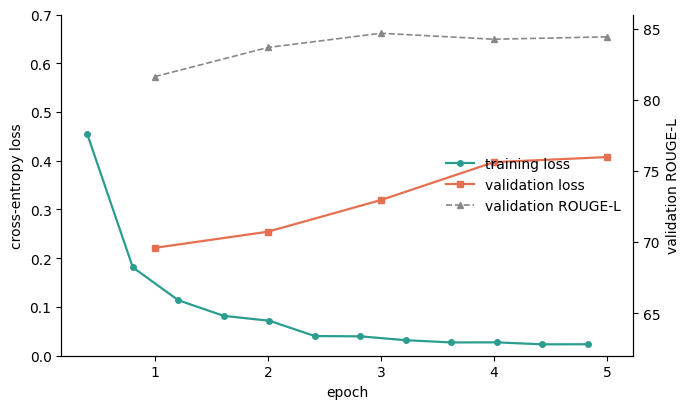

In [2]:
tr_x = [d["epoch"] for d in train]
tr_y = [d["loss"] for d in train]
ev_x = [d["epoch"] for d in evals]
ev_y = [d["eval_loss"] for d in evals]
ev_r = [d["eval_rougeL"] for d in evals]

fig, ax1 = plt.subplots(figsize=(7, 4.2))
teal, red, gray = "#2a9d8f", "#e76f51", "#888888"

ax1.plot(tr_x, tr_y, "-o", color=teal, ms=4, lw=1.6, label="training loss")
ax1.plot(ev_x, ev_y, "-s", color=red, ms=5, lw=1.6, label="validation loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("cross-entropy loss")
ax1.set_xticks(range(0, 6))
ax1.spines["top"].set_visible(False)

# right axis: validation ROUGE-L, to show the task metric still improves
ax2 = ax1.twinx()
ax2.plot(ev_x, ev_r, "--^", color=gray, ms=5, lw=1.2, label="validation ROUGE-L")
ax2.set_ylabel("validation ROUGE-L")
ax2.spines["top"].set_visible(False)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, frameon=False, loc="center right")
ax1.set_ylim(0, 0.7); ax2.set_ylim(62, 86); fig.tight_layout()
fig.savefig(OUT, dpi=150, bbox_inches="tight")
print("wrote", OUT)
plt.show()